In [1]:
# ==========================================================
# CELL 1: IMPORT LIBRARIES

# Import all required libraries for data cleaning and preprocessing.

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore unnecessary warnings for cleaner notebook output.
warnings.filterwarnings("ignore")

# Configure pandas display options.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 100)

# Configure visualization style.
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Print library versions for reproducibility.
print("=" * 70)
print("LIBRARY VERSIONS")
print("=" * 70)
print(f"Pandas     : {pd.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Matplotlib : {plt.matplotlib.__version__}")
print(f"Seaborn    : {sns.__version__}")
print("=" * 70)

LIBRARY VERSIONS
Pandas     : 3.0.3
NumPy      : 2.4.6
Matplotlib : 3.11.0
Seaborn    : 0.13.2


In [2]:
# ==========================================================
# CELL 2: LOAD DATASET

# Define dataset path.
DATASET_PATH = Path(r"C:\Users\bts\OneDrive\Desktop\Auspify\Dataset\Dataset.csv")


def load_dataset(path: Path) -> pd.DataFrame:
    """
    Load dataset safely.

    Parameters
    ----------
    path : pathlib.Path
        Dataset location.

    Returns
    -------
    pd.DataFrame
    """

    try:
        if not path.exists():
            raise FileNotFoundError(f"Dataset not found:\n{path}")

        dataframe = pd.read_csv(path)

        print("=" * 70)
        print("DATASET LOADED SUCCESSFULLY")
        print("=" * 70)
        print(f"Location : {path}")
        print(f"Rows     : {dataframe.shape[0]}")
        print(f"Columns  : {dataframe.shape[1]}")

        return dataframe

    except Exception as error:
        print(f"Error while loading dataset:\n{error}")
        raise


# Load dataset.
df = load_dataset(DATASET_PATH)

# Store original shape for later comparison.
original_shape = df.shape

# Display first five rows.
print("\nFIRST FIVE ROWS\n")
display(df.head())

print("\nDATASET SHAPE")
print(df.shape)

DATASET LOADED SUCCESSFULLY
Location : C:\Users\bts\OneDrive\Desktop\Auspify\Dataset\Dataset.csv
Rows     : 8790
Columns  : 10

FIRST FIVE ROWS



,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure"
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"



DATASET SHAPE
(8790, 10)


In [3]:
# ==========================================================
# CELL 3: INITIAL DATA EXPLORATION

# Perform an initial exploration of the dataset.


def memory_usage_mb(dataframe: pd.DataFrame) -> float:
    """
    Calculate dataframe memory usage in MB.
    """
    return dataframe.memory_usage(deep=True).sum() / (1024 ** 2)


print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

df.info()

print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

display(df.describe(include="all").T)

print("\n" + "=" * 70)
print("COLUMN NAMES")
print("=" * 70)

for idx, column in enumerate(df.columns, start=1):
    print(f"{idx:02d}. {column}")

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

display(df.dtypes.to_frame(name="Data Type"))

print("\n" + "=" * 70)
print("MEMORY USAGE")
print("=" * 70)

print(f"Memory Usage : {memory_usage_mb(df):.2f} MB")

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8790 non-null   str  
 1   type          8790 non-null   str  
 2   title         8790 non-null   str  
 3   director      8790 non-null   str  
 4   country       8790 non-null   str  
 5   date_added    8790 non-null   str  
 6   release_year  8790 non-null   int64
 7   rating        8790 non-null   str  
 8   duration      8790 non-null   str  
 9   listed_in     8790 non-null   str  
dtypes: int64(1), str(9)
memory usage: 1.6 MB

DESCRIPTIVE STATISTICS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8790,8790,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8790,2,Movie,6126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8790,8787,9-Feb,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,8790,4528,Not Given,2588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,8790,86,United States,3240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8790,1713,1/1/2020,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8790.0,NaN,NaN,NaN,2014.183163,8.825466,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8790,14,TV-MA,3205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8790,220,1 Season,1791,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listed_in,8790,513,"Dramas, International Movies",362,NaN,NaN,NaN,NaN,NaN,NaN,NaN



COLUMN NAMES
01. show_id
02. type
03. title
04. director
05. country
06. date_added
07. release_year
08. rating
09. duration
10. listed_in

DATA TYPES


,Data Type
show_id,str
type,str
title,str
director,str
country,str
date_added,str
release_year,int64
rating,str
duration,str
listed_in,str



MEMORY USAGE
Memory Usage : 1.55 MB


MISSING VALUE SUMMARY


,Missing Values,Missing Percentage
show_id,0,0.0
type,0,0.0
title,0,0.0
director,0,0.0
country,0,0.0
date_added,0,0.0
release_year,0,0.0
rating,0,0.0
duration,0,0.0
listed_in,0,0.0



Total Missing Values : 0


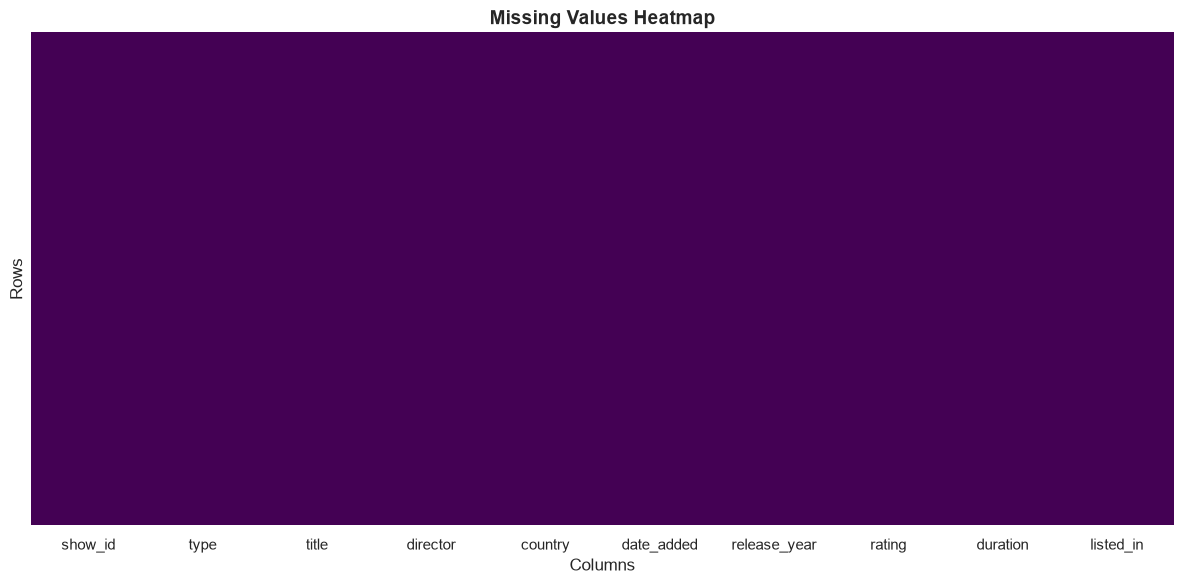

In [4]:
# ==========================================================
# CELL 4: CHECK MISSING VALUES

# Analyze missing values and visualize them.


def missing_value_summary(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Create missing value summary.
    """

    summary = pd.DataFrame({
        "Missing Values": dataframe.isnull().sum(),
        "Missing Percentage": (
            dataframe.isnull().mean() * 100
        ).round(2)
    })

    summary = summary.sort_values(
        by="Missing Percentage",
        ascending=False
    )

    return summary


missing_summary = missing_value_summary(df)

print("=" * 70)
print("MISSING VALUE SUMMARY")
print("=" * 70)

display(missing_summary)

# Store total missing values before cleaning.
missing_before = int(df.isnull().sum().sum())

print(f"\nTotal Missing Values : {missing_before}")

# Heatmap visualization.
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cmap="viridis",
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap", fontsize=14, weight="bold")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.tight_layout()
plt.show()

In [5]:
# ==========================================================
# CELL 5: CHECK DUPLICATES

# Identify and remove duplicate records.


duplicate_count = df.duplicated().sum()

print("=" * 70)
print("DUPLICATE RECORD ANALYSIS")
print("=" * 70)

print(f"Duplicate Records Found : {duplicate_count}")

duplicates_removed = duplicate_count

if duplicate_count > 0:

    df = df.drop_duplicates().reset_index(drop=True)

    print(f"\nRemoved {duplicates_removed} duplicate rows.")

else:

    print("\nNo duplicate rows found.")

print("\nVerification")

print(f"Remaining Duplicates : {df.duplicated().sum()}")

print("\nUpdated Dataset Shape")

print(df.shape)

DUPLICATE RECORD ANALYSIS
Duplicate Records Found : 0

No duplicate rows found.

Verification
Remaining Duplicates : 0

Updated Dataset Shape
(8790, 10)


In [6]:
# ==========================================================
# CELL 6: STANDARDIZE COLUMN NAMES

# Clean and standardize column names for consistency.


def clean_column_name(column: str) -> str:
    """
    Standardize column names.

    - lowercase
    - trim spaces
    - replace spaces with underscore
    - remove special characters
    """

    column = column.strip().lower()
    column = re.sub(r"\s+", "_", column)
    column = re.sub(r"[^\w]", "", column)
    column = re.sub(r"_+", "_", column)

    return column


original_columns = df.columns.tolist()

df.columns = [clean_column_name(col) for col in df.columns]

print("=" * 70)
print("COLUMN NAME STANDARDIZATION")
print("=" * 70)

comparison = pd.DataFrame({
    "Original Column": original_columns,
    "Standardized Column": df.columns
})

display(comparison)

print("\nUpdated Columns:\n")

print(df.columns.tolist())

COLUMN NAME STANDARDIZATION


,Original Column,Standardized Column
0,show_id,show_id
1,type,type
2,title,title
3,director,director
4,country,country
5,date_added,date_added
6,release_year,release_year
7,rating,rating
8,duration,duration
9,listed_in,listed_in



Updated Columns:

['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in']


In [7]:
# ==========================================================
# CELL 7: HANDLE MISSING VALUES

# Automatically detect numeric and categorical columns and
# impute missing values using median (numeric) and mode (categorical).

# Store missing values before cleaning for project summary.
missing_before_cleaning = df.isna().sum().sum()


def handle_missing_values(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Handle missing values automatically.

    Numeric Columns:
        Fill with median.

    Categorical Columns:
        Fill with mode.

    Returns
    -------
    pd.DataFrame
    """

    dataframe = dataframe.copy()

    numeric_cols = dataframe.select_dtypes(include=[np.number]).columns
    categorical_cols = dataframe.select_dtypes(
        include=["object", "category"]
    ).columns

    print("=" * 70)
    print("HANDLING NUMERIC COLUMNS")
    print("=" * 70)

    for column in numeric_cols:

        missing = dataframe[column].isna().sum()

        if missing > 0:

            median_value = dataframe[column].median()

            dataframe[column] = dataframe[column].fillna(median_value)

            print(
                f"{column:<30} "
                f"Filled {missing:<6} "
                f"Median = {median_value}"
            )

    print("\n" + "=" * 70)
    print("HANDLING CATEGORICAL COLUMNS")
    print("=" * 70)

    for column in categorical_cols:

        missing = dataframe[column].isna().sum()

        if missing > 0:

            mode_value = dataframe[column].mode(dropna=True)

            if not mode_value.empty:
                dataframe[column] = dataframe[column].fillna(mode_value.iloc[0])

            print(
                f"{column:<30} "
                f"Filled {missing:<6}"
            )

    return dataframe


df = handle_missing_values(df)

missing_after_cleaning = df.isna().sum().sum()

print("\n" + "=" * 70)
print("MISSING VALUE TREATMENT COMPLETED")
print("=" * 70)
print(f"Before : {missing_before_cleaning}")
print(f"After  : {missing_after_cleaning}")

HANDLING NUMERIC COLUMNS

HANDLING CATEGORICAL COLUMNS

MISSING VALUE TREATMENT COMPLETED
Before : 0
After  : 0


In [8]:
# ==========================================================
# CELL 8: CLEAN STRING COLUMNS

# Clean textual columns by:
# - Removing leading/trailing spaces
# - Removing multiple spaces
# - Removing unnecessary symbols
# - Converting text to Title Case where appropriate


def clean_text(value):

    if pd.isna(value):
        return value

    value = str(value)

    value = value.strip()

    value = value.replace("\n", " ")

    value = value.replace("\t", " ")

    value = value.replace("|", "")

    value = value.replace('"', "")

    value = value.replace("'", "")

    value = " ".join(value.split())

    return value.title()


object_columns = df.select_dtypes(include="object").columns

print("=" * 70)
print("CLEANING STRING COLUMNS")
print("=" * 70)

for column in object_columns:

    df[column] = df[column].apply(clean_text)

    print(f"Cleaned -> {column}")

print("\nString cleaning completed successfully.")

CLEANING STRING COLUMNS
Cleaned -> show_id
Cleaned -> type
Cleaned -> title
Cleaned -> director
Cleaned -> country
Cleaned -> date_added
Cleaned -> rating
Cleaned -> duration
Cleaned -> listed_in

String cleaning completed successfully.


In [9]:
# ==========================================================
# CELL 9: DATE PREPROCESSING

# Automatically detect possible date columns and convert them
# into datetime format.


date_keywords = [
    "date",
    "added",
    "release",
    "year",
    "time"
]


date_columns = []

for column in df.columns:

    column_lower = column.lower()

    if any(keyword in column_lower for keyword in date_keywords):
        date_columns.append(column)

print("=" * 70)
print("DATE COLUMN DETECTION")
print("=" * 70)

if len(date_columns) == 0:

    print("No probable date columns detected.")

else:

    for column in date_columns:

        try:

            converted = pd.to_datetime(
                df[column],
                errors="coerce"
            )

            # Convert only if at least one valid date exists.
            if converted.notna().sum() > 0:

                df[column] = converted

                df[f"{column}_year"] = df[column].dt.year

                df[f"{column}_month"] = df[column].dt.month

                df[f"{column}_day"] = df[column].dt.day

                print(f"Processed -> {column}")

            else:

                print(f"Skipped -> {column}")

        except Exception as error:

            print(f"{column} : {error}")

DATE COLUMN DETECTION
Processed -> date_added
Processed -> release_year


In [10]:
# ==========================================================
# CELL 10: CATEGORICAL TRANSFORMATION

# Convert suitable object columns into category dtype to
# optimize memory usage.


object_columns = df.select_dtypes(include="object").columns

converted_columns = []

for column in object_columns:

    unique_ratio = df[column].nunique(dropna=False) / len(df)

    # Convert only if unique values are relatively low.
    if unique_ratio < 0.50:

        df[column] = df[column].astype("category")

        converted_columns.append(column)

print("=" * 70)
print("CATEGORICAL TRANSFORMATION")
print("=" * 70)

if converted_columns:

    print("Converted Columns:\n")

    for column in converted_columns:
        print(column)

else:

    print("No suitable columns found for category conversion.")

CATEGORICAL TRANSFORMATION
Converted Columns:

type
country
rating
duration
listed_in


In [11]:
# ==========================================================
# CELL 11: OUTLIER ANALYSIS

# Detect potential outliers using the Interquartile Range (IQR)
# method without removing them.


numeric_columns = df.select_dtypes(include=np.number).columns

outlier_summary = []

for column in numeric_columns:

    q1 = df[column].quantile(0.25)

    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr

    upper = q3 + 1.5 * iqr

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ].shape[0]

    outlier_summary.append(
        {
            "Column": column,
            "Outliers": outliers,
            "Lower Bound": round(lower, 2),
            "Upper Bound": round(upper, 2)
        }
    )

outlier_summary = pd.DataFrame(outlier_summary)

print("=" * 70)
print("OUTLIER ANALYSIS (IQR)")
print("=" * 70)

display(outlier_summary)

print("\nNote:")
print("Potential outliers are reported only.")
print("No records were removed automatically.")

OUTLIER ANALYSIS (IQR)


,Column,Outliers,Lower Bound,Upper Bound
0,date_added_year,56,2015.0,2023.0
1,date_added_month,0,-5.0,19.0
2,date_added_day,0,-27.5,48.5
3,release_year_year,0,1970.0,1970.0
4,release_year_month,0,1.0,1.0
5,release_year_day,0,1.0,1.0



Note:
Potential outliers are reported only.
No records were removed automatically.


In [13]:
# ==========================================================
# CELL 12: FEATURE ENGINEERING

# Create useful engineered features dynamically based on the
# available dataset columns.

created_features = []

# ----------------------------------------------------------
# Feature 1
# Content Age
# ----------------------------------------------------------

year_columns = [
    col for col in df.columns
    if "release_year" in col.lower()
]

if year_columns:

    column = year_columns[0]

    current_year = pd.Timestamp.today().year

    # Case 1 : Datetime column
    if pd.api.types.is_datetime64_any_dtype(df[column]):

        df["content_age"] = current_year - df[column].dt.year

    # Case 2 : Numeric year column
    elif pd.api.types.is_numeric_dtype(df[column]):

        df["content_age"] = current_year - df[column]

    # Case 3 : String/object column
    else:

        year_series = pd.to_numeric(df[column], errors="coerce")

        df["content_age"] = current_year - year_series

    created_features.append("content_age")


# ----------------------------------------------------------
# Feature 2
# Duration Category
# ----------------------------------------------------------

duration_columns = [
    column for column in df.columns
    if "duration" in column.lower()
]

if len(duration_columns) > 0:

    duration_column = duration_columns[0]

    numeric_duration = (
        df[duration_column]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(float)
    )

    numeric_duration = numeric_duration[0]

    df["duration_category"] = pd.cut(
        numeric_duration,
        bins=[0, 60, 120, 180, np.inf],
        labels=[
            "Short",
            "Medium",
            "Long",
            "Very Long"
        ]
    )

    created_features.append("duration_category")


# ----------------------------------------------------------
# Feature 3
# Cast Count (Optional)
# ----------------------------------------------------------

cast_columns = [
    column for column in df.columns
    if "cast" in column.lower()
]

if len(cast_columns) > 0:

    cast_column = cast_columns[0]

    df["cast_count"] = (
        df[cast_column]
        .astype(str)
        .str.count(",")
        .add(1)
    )

    created_features.append("cast_count")


print("=" * 70)
print("FEATURE ENGINEERING")
print("=" * 70)

if created_features:

    print("Created Features:\n")

    for feature in created_features:
        print(f"✓ {feature}")

else:

    print("No dataset-specific engineered features could be created.")

FEATURE ENGINEERING
Created Features:

✓ content_age
✓ duration_category


In [14]:
# ==========================================================
# CELL 13: DATA CONSISTENCY CHECK

# Perform final consistency checks before saving the cleaned dataset.


def data_consistency_report(dataframe: pd.DataFrame) -> None:
    """
    Generate a comprehensive data consistency report.
    """

    print("=" * 70)
    print("DATA CONSISTENCY REPORT")
    print("=" * 70)

    # Remaining missing values
    remaining_missing = dataframe.isnull().sum().sum()

    # Remaining duplicate rows
    remaining_duplicates = dataframe.duplicated().sum()

    print(f"Remaining Missing Values   : {remaining_missing}")
    print(f"Remaining Duplicate Rows   : {remaining_duplicates}")

    print("\n" + "=" * 70)
    print("INVALID VALUES CHECK")
    print("=" * 70)

    numeric_columns = dataframe.select_dtypes(include=np.number).columns

    if len(numeric_columns) > 0:

        invalid_numeric = pd.DataFrame({
            "Negative Values":
                (dataframe[numeric_columns] < 0).sum(),
            "Zero Values":
                (dataframe[numeric_columns] == 0).sum()
        })

        display(invalid_numeric)

    print("\n" + "=" * 70)
    print("UNIQUE CATEGORIES")
    print("=" * 70)

    categorical_columns = dataframe.select_dtypes(
        include=["object", "category"]
    ).columns

    for column in categorical_columns:

        print(f"\n{column}")

        print("-" * len(column))

        print(f"Unique Values : {dataframe[column].nunique()}")

        preview = dataframe[column].dropna().unique()[:10]

        print(f"Sample Values : {list(preview)}")


data_consistency_report(df)

DATA CONSISTENCY REPORT
Remaining Missing Values   : 0
Remaining Duplicate Rows   : 0

INVALID VALUES CHECK


,Negative Values,Zero Values
date_added_year,0,0
date_added_month,0,0
date_added_day,0,0
release_year_year,0,0
release_year_month,0,0
release_year_day,0,0
content_age,0,0



UNIQUE CATEGORIES

show_id
-------
Unique Values : 8790
Sample Values : ['S1', 'S3', 'S6', 'S14', 'S8', 'S9', 'S10', 'S939', 'S13', 'S940']

type
----
Unique Values : 2
Sample Values : ['Movie', 'Tv Show']

title
-----
Unique Values : 8781
Sample Values : ['Dick Johnson Is Dead', 'Ganglands', 'Midnight Mass', 'Confessions Of An Invisible Girl', 'Sankofa', 'The Great British Baking Show', 'The Starling', 'Motu Patlu In The Game Of Zones', 'Je Suis Karl', 'Motu Patlu In Wonderland']

director
--------
Unique Values : 4526
Sample Values : ['Kirsten Johnson', 'Julien Leclercq', 'Mike Flanagan', 'Bruno Garotti', 'Haile Gerima', 'Andy Devonshire', 'Theodore Melfi', 'Suhas Kadav', 'Christian Schwochow', 'Not Given']

country
-------
Unique Values : 86
Sample Values : ['United States', 'France', 'Brazil', 'United Kingdom', 'India', 'Germany', 'Pakistan', 'Not Given', 'China', 'South Africa']

rating
------
Unique Values : 14
Sample Values : ['Pg-13', 'Tv-Ma', 'Tv-Pg', 'Tv-14', 'Tv-Y7', 'Tv-Y'

In [15]:
# ==========================================================
# CELL 14: FINAL DATASET SUMMARY

# Display final information after preprocessing.


def dataset_summary(dataframe: pd.DataFrame) -> None:
    """
    Display dataset summary.
    """

    print("=" * 70)
    print("FINAL DATASET SUMMARY")
    print("=" * 70)

    print(f"Shape              : {dataframe.shape}")

    print(f"Rows               : {dataframe.shape[0]}")

    print(f"Columns            : {dataframe.shape[1]}")

    memory = dataframe.memory_usage(deep=True).sum() / (1024 ** 2)

    print(f"Memory Usage       : {memory:.2f} MB")

    print("\n" + "=" * 70)
    print("COLUMN NAMES")
    print("=" * 70)

    for column in dataframe.columns:
        print(column)

    print("\n" + "=" * 70)
    print("DATA TYPES")
    print("=" * 70)

    display(dataframe.dtypes.to_frame(name="Data Type"))


dataset_summary(df)

FINAL DATASET SUMMARY
Shape              : (8790, 18)
Rows               : 8790
Columns            : 18
Memory Usage       : 0.97 MB

COLUMN NAMES
show_id
type
title
director
country
date_added
release_year
rating
duration
listed_in
date_added_year
date_added_month
date_added_day
release_year_year
release_year_month
release_year_day
content_age
duration_category

DATA TYPES


,Data Type
show_id,str
type,category
title,str
director,str
country,category
date_added,datetime64[us]
release_year,datetime64[ns]
rating,category
duration,category
listed_in,category


In [16]:
# ==========================================================
# CELL 15: SAVE CLEAN DATASET

# Save the cleaned dataset into the current working directory.

from pathlib import Path

OUTPUT_FILE = Path.cwd() / "clean_netflix_dataset.csv"

try:

    df.to_csv(OUTPUT_FILE, index=False)

    print("=" * 70)
    print("DATASET SAVED SUCCESSFULLY")
    print("=" * 70)

    print(f"Location : {OUTPUT_FILE.resolve()}")

except Exception as error:

    print(f"Unable to save dataset.\n{error}")

DATASET SAVED SUCCESSFULLY
Location : C:\Users\bts\OneDrive\Desktop\Auspify\Task-1\clean_netflix_dataset.csv


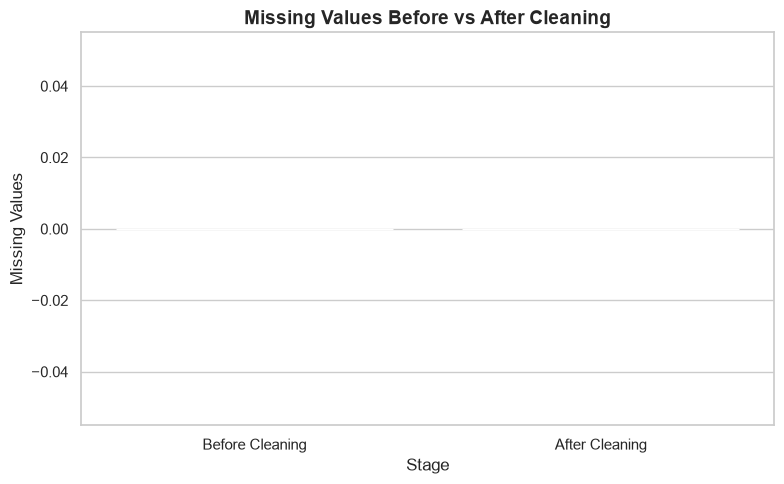

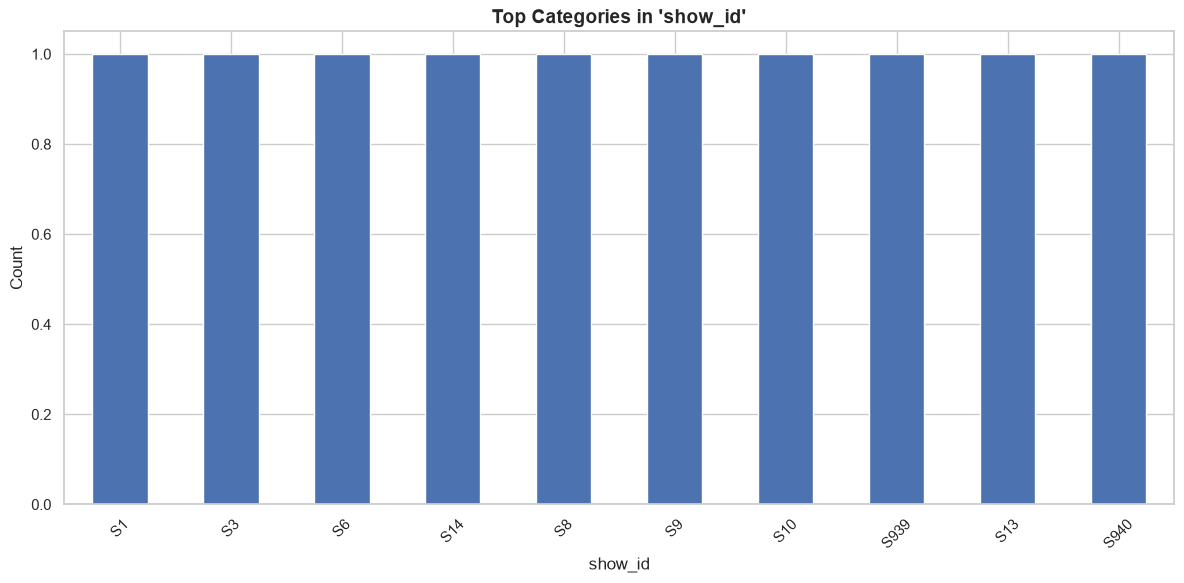

In [17]:
# ==========================================================
# CELL 16: VISUALIZATION

# Create professional visualizations for the cleaned dataset.

plt.figure(figsize=(8, 5))

before_after = pd.DataFrame({
    "Stage": ["Before Cleaning", "After Cleaning"],
    "Missing Values": [
        missing_before_cleaning,
        df.isnull().sum().sum()
    ]
})

sns.barplot(
    data=before_after,
    x="Stage",
    y="Missing Values"
)

plt.title(
    "Missing Values Before vs After Cleaning",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


# ----------------------------------------------------------

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

if len(categorical_columns) > 0:

    best_column = max(
        categorical_columns,
        key=lambda col: df[col].nunique()
    )

    plt.figure(figsize=(12, 6))

    (
        df[best_column]
        .value_counts()
        .head(10)
        .plot(kind="bar")
    )

    plt.title(
        f"Top Categories in '{best_column}'",
        fontsize=14,
        fontweight="bold"
    )

    plt.ylabel("Count")

    plt.xlabel(best_column)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

else:

    print("No categorical columns available for visualization.")

In [18]:
# ==========================================================
# CELL 17: PROJECT SUMMARY

# Display a professional project summary.

final_shape = df.shape

rows_removed = original_shape[0] - final_shape[0]

duplicates_removed = duplicates_removed

new_features_created = len(created_features)

print("=" * 70)
print("PROJECT SUMMARY")
print("=" * 70)

print(f"{'Original Shape':35}: {original_shape}")

print(f"{'Final Shape':35}: {final_shape}")

print(f"{'Rows Removed':35}: {rows_removed}")

print(f"{'Duplicate Records Removed':35}: {duplicates_removed}")

print(
    f"{'Missing Values Fixed':35}: "
    f"{missing_before_cleaning - df.isnull().sum().sum()}"
)

print(f"{'New Features Created':35}: {new_features_created}")

print(
    f"{'Cleaning Status':35}: "
    "Completed Successfully"
)

print("=" * 70)

PROJECT SUMMARY
Original Shape                     : (8790, 10)
Final Shape                        : (8790, 18)
Rows Removed                       : 0
Duplicate Records Removed          : 0
Missing Values Fixed               : 0
New Features Created               : 2
Cleaning Status                    : Completed Successfully


In [19]:
# ==========================================================
# CELL 18: COMPLETION MESSAGE

print("=" * 60)

print("Task Completed Successfully")

print()

print("Task:")
print("Netflix Data Cleaning & Preprocessing")

print()

print("Intern:")
print("Aarush Tyagi")

print()

print("Organization:")
print("Auspify Technologies")

print()

print("Status:")
print("Ready for EDA & Machine Learning")

print("=" * 60)

Task Completed Successfully

Task:
Netflix Data Cleaning & Preprocessing

Intern:
Aarush Tyagi

Organization:
Auspify Technologies

Status:
Ready for EDA & Machine Learning
